In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import BRICS
from rdkit.Chem import rdDepictor
rdDepictor.SetPreferCoordGen(True)
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from tqdm import tqdm
import concurrent.futures

In [2]:
df = pd.read_csv("data/linkers.csv", encoding = 'latin1')

In [3]:
df.head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,Molecular Weight,K-means,scaffold_smiles,source
0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,CC(=O)N[C@@H](CC1=CC=CC=C1)C(=O)N[C@@H](CCCCNC...,3.508295,204.30,0.036588,4.5636,689.72,12,O=C(CCc1ccccc1)NCC(=O)Nc1ccc(COC(=O)Oc2ccccc2)cc1,train
1,1,1,1,6-Maleimidohexanoic acid N-hydroxysuccinimide ...,C1CC(=O)N(C1=O)OC(=O)CCCCCN2C(=O)C=CC2=O,2.676214,101.06,0.487410,0.0790,308.29,4,O=C(CCCCCN1C(=O)C=CC1=O)ON1C(=O)CCC1=O,train
2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,3.338596,171.88,0.163403,3.6140,601.70,12,O=C(CNC(=O)OCC1c2ccccc2-c2ccccc21)NCC(=O)Nc1cc...,train
3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,3.753739,230.32,0.030495,5.7455,766.81,12,O=C(CNC(=O)OCC1c2ccccc2-c2ccccc21)NCC(=O)Nc1cc...,train
4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,3.796268,258.47,0.032958,2.8084,737.77,12,O=C(CCCCCN1C(=O)C=CC1=O)NCC(=O)NCC(=O)Nc1ccc(C...,train


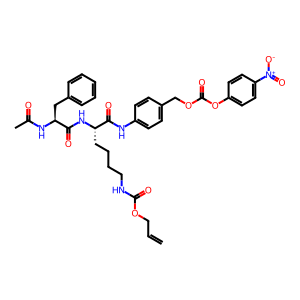

In [4]:
mol = Chem.MolFromSmiles("CC(=O)N[C@@H](CC1=CC=CC=C1)C(=O)N[C@@H](CCCCNC(=O)OCC=C)C(=O)NC2=CC=C(C=C2)COC(=O)OC3=CC=C(C=C3)[N+](=O)[O-]")
Draw.MolToImage(mol)

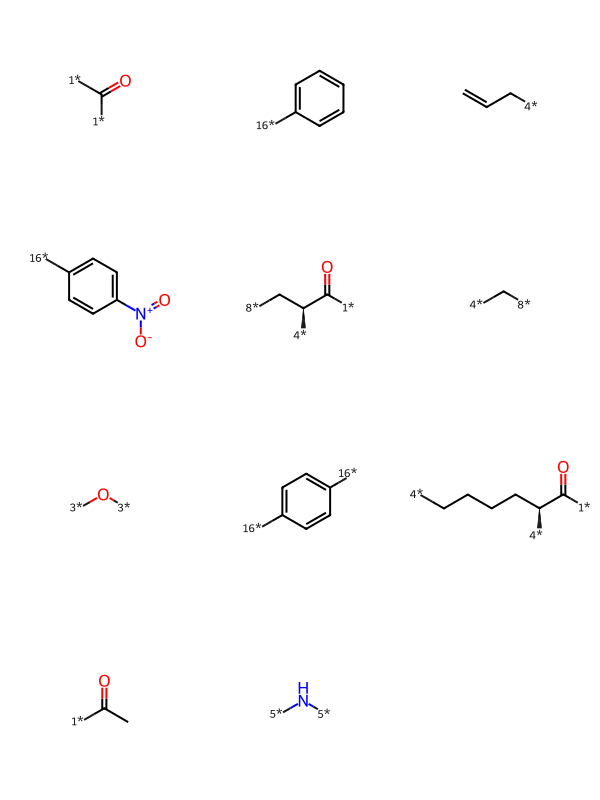

In [5]:
frags = BRICS.BRICSDecompose(mol)
Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in frags])

In [4]:
frags

NameError: name 'frags' is not defined

In [5]:
all_fragments = []

skipped_count = 0
for i, smile in enumerate(df['smiles']):
    print(f"{i+1}/{len(df)}, skipped = {skipped_count}", end='\r')
    mol = Chem.MolFromSmiles(smile)

    if mol is None:
        skipped_count += 1
        continue
    
    if mol.GetNumAtoms() > 500:
        skipped_count += 1
        continue

    frags = BRICS.BreakBRICSBonds(mol)
    frag_smiles = Chem.MolToSmiles(frags).split('.')
    all_fragments.extend(frag_smiles)

In [6]:
frags_series = pd.Series(all_fragments)
frags_df = pd.DataFrame(frags_series.value_counts().reset_index())
frags_df = frags_df.rename(columns={'index': 'frags'})
frags_df

,frags,count
0,[3*]O[3*],31673
1,[4*]CC[4*],29166
2,[5*]N[5*],1975
3,[1*]C(=O)CC[4*],1420
4,[4*]C(C)(C)C,985
...,...,...
276,[1*]C(=O)CCC([4*])C([1*])=O,1
277,[1*]C(=O)CCCCC(=O)O,1
278,[1*]C(=O)C(C)(C)Br,1
279,[1*]C(=O)CCCCCCCCCCCCCCCCC(=O)O,1


In [7]:
def label_frags(smile):
    stars = smile.count('*')
    if stars == 1: return "Terminal (Head/Tail)"
    if stars == 2: return "Linker (Spacer/Cleavable)"
    return "Branching/Complex"

frags_df['Category'] = frags_df['frags'].apply(label_frags)

In [8]:
frags_df

,frags,count,Category
0,[3*]O[3*],31673,Linker (Spacer/Cleavable)
1,[4*]CC[4*],29166,Linker (Spacer/Cleavable)
2,[5*]N[5*],1975,Linker (Spacer/Cleavable)
3,[1*]C(=O)CC[4*],1420,Linker (Spacer/Cleavable)
4,[4*]C(C)(C)C,985,Terminal (Head/Tail)
...,...,...,...
276,[1*]C(=O)CCC([4*])C([1*])=O,1,Branching/Complex
277,[1*]C(=O)CCCCC(=O)O,1,Terminal (Head/Tail)
278,[1*]C(=O)C(C)(C)Br,1,Terminal (Head/Tail)
279,[1*]C(=O)CCCCCCCCCCCCCCCCC(=O)O,1,Terminal (Head/Tail)


In [9]:
print("Top Spacers/Linkers:")
print(frags_df[frags_df['Category'].str.contains("Linker")].head(40))

print("\nTop Heads/Tails:")
print(frags_df[frags_df['Category'].str.contains("Terminal")].head(40))

Top Spacers/Linkers:
                                  frags  count                   Category
0                             [3*]O[3*]  31673  Linker (Spacer/Cleavable)
1                            [4*]CC[4*]  29166  Linker (Spacer/Cleavable)
2                             [5*]N[5*]   1975  Linker (Spacer/Cleavable)
3                       [1*]C(=O)CC[4*]   1420  Linker (Spacer/Cleavable)
6                         [1*]C([1*])=O    695  Linker (Spacer/Cleavable)
15                    [1*]C(=O)CCCC[8*]    239  Linker (Spacer/Cleavable)
16                            [4*]C[8*]    231  Linker (Spacer/Cleavable)
20                      [1*]C(=O)CC[8*]    190  Linker (Spacer/Cleavable)
21                      [1*]C(=O)NO[3*]    164  Linker (Spacer/Cleavable)
22                 [16*]c1ccc([16*])cc1    161  Linker (Spacer/Cleavable)
26                         [11*]SS[11*]    150  Linker (Spacer/Cleavable)
28                       [1*]C(=O)C[4*]    132  Linker (Spacer/Cleavable)
29               

In [10]:
head_smarts = [
    # --- Standard Conjugation ---
    "[10*]N1C(=O)C=CC1=O",            # (13) Maleimide (Cysteine target)
    "[3*]ON1C(=O)CCC1=O",             # (8) NHS Ester (Lysine target)
    "[63]ON1C(=O)CC(S(=O)(=O)O)C1=O", # (63) Sulfo-NHS (Water soluble NHS)
    "[4*]CCBr",                       # (17) Bromoethyl (Alkylation)
    "[1*]C(=O)CBr",                   # (38) Bromoacetyl (Alkylation)
    "[13*][C@@H]1SC[C@@H]2NC(=O)N[C@@H]21", # (18) Biotin (Affinity Binding)
    "[4*]CCC(=O)NN",                  # (62) Hydrazide (Reacts with Aldehydes)
    "[16*]c1ccc(C=O)cc1",             # (36) Benzaldehyde (Reacts with Hydrazines)

    # --- Click Chemistry (Bio-orthogonal) ---
    "[4*]CCN=[N+]=[N-]",              # (7) Azide
    "[4*]CC#C",                       # (12) Alkyne
    "[5*]N1Cc2ccccc2C#Cc2ccccc21",    # (14) DBCO (Copper-free click)
    "[15*]C1CC/C=C\CCC1",             # (40) TCO (Trans-cyclooctene)
    "[14*]c1nnc(C)nn1",               # (39) Tetrazine/Triazine
    "[15*]C1[C@H]2CCC#CCC[C@@H]12",   # (45) BCN (Strained alkyne)
    "[15*]C1C2CCC#CCCC12",            # (50) Cyclooctyne variant

    # --- Activated Esters / Leaving Groups ---
    "[16*]c1c(F)c(F)c(F)c(F)c1F",     # (31) PFP (Pentafluorophenyl ester)
    "[16*]c1c(F)c(F)cc(F)c1F",        # (57) TFP (Tetrafluorophenyl ester)
    "[16*]c1ccc([N+](=O)[O-])cc1",    # (52) Nitrophenyl ester
    "[16*]c1ccc([N+](=O)[O-])cc1[N+](=O)[O-]", # (54) Dinitrophenyl
    "[3*]OS(=O)(=O)c1ccc(C)cc1",      # (30) Tosylate (Leaving group)
    "[3*]OS(C)(=O)=O",                # (41) Mesylate (Leaving group)
]

tail_smarts = [
    # --- Functional Tails (Drug Attachment) ---
    "[4*]CCC(=O)O",                   # (5) Propionic Acid
    "[4*]CC(=O)O",                    # (24) Acetic Acid
    "[4*]CCN",                        # (11) Ethylamine
    "[5*]NC",                         # (35) Methylamine
    "[16*]c1ccccc1",                  # (25) Phenyl (Likely PABC end)
    "[4*]CCS",                        # (44) Thiol (Mercaptan)
    "[11*]SC(C)=O",                   # (55) Thioacetate (Protected Thiol)
    "[3*]ON",                         # (23) Hydroxylamine

    # --- Caps & Protecting Groups ---
    "[4*]C(C)(C)C",                   # (4) t-Butyl (Boc protection / Hydrophobic cap)
    "[4*]CC1c2ccccc2-c2ccccc21",      # (34) Fluorenyl (Fmoc protection)
    "[4*]CCO",                        # (9) Ether/Alcohol
    "[3*]OC",                         # (10) Methoxy
    "[4*]CC",                         # (27) Ethyl
    "[14*]c1ccccn1",                  # (37) Pyridine cap
    "[1*]C(N)=O",                     # (42) Amide cap
    "[4*]CCS(=O)(=O)O",               # (47) Sulfonate (Solubility cap)
    "[8*]CO",                         # (51) Methoxy variant
    "[1*]C(C)=O",                     # (53) Acetyl cap
    "[8*]CCC(=O)CC(C)=O",             # (58) Levulinyl (Protecting group)
]

<>:16: SyntaxWarning: invalid escape sequence '\C'
<>:16: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_85660/1455708684.py:16: SyntaxWarning: invalid escape sequence '\C'
  "[15*]C1CC/C=C\CCC1",             # (40) TCO (Trans-cyclooctene)


In [11]:
spacer_unit_smarts = [
    # --- Original Spacers ---
    "[3*]O[3*]",                # Oxygen (Ether)
    "[4*]CC[4*]",               # Ethyl
    "[5*]N[5*]",                # Nitrogen (Secondary amine)
    "[1*]C(=O)CC[4*]",          # Propionyl extender
    "[1*]C([1*])=O",            # Carbonyl
    "[1*]C(=O)CCCC[8*]",        # Valeryl extender
    "[4*]C[8*]",                # Methyl bridge
    "[1*]C(=O)CC[8*]",          # Propionyl variant
    "[1*]C(=O)NO[3*]",          # Alkoxyamine
    "[1*]C(=O)C[4*]",           # Acetyl
    "[1*]C(=O)CCC([1*])=O",     # Glutaric
    "[4*]CC[8*]",               # Ethyl variant
    "[1*]C([6*])=O",            # Carbonyl variant
    "[1*]C(=O)CCC[4*]",         # Butyryl
    "[4*]CCC[4*]",              # Propyl
    "[4*]C([8*])C",             # Iso-propyl

    # --- New Additions (Structural) ---
    "[1*]C(=O)CCCCC[8*]",       # (60) Hexanoyl/Caproyl extender
    "[1*]C(=O)C(C[4*])S(=O)(=O)O", # (69) Sulfonated alkyl (Solubility spacer)
    "[1*]C(=O)CCCCC([1*])=O",   # (73) Pimelic (Longer Glutaric)
    "[5*]N([5*])C",             # (74) Methylamine bridge
    "[4*]CCS(=O)(=O)CC[4*]",    # (77) Sulfone bridge
    "[11*]S[11*]",              # (82) Thioether (Single sulfur is stable, unlike SS)
    "[14*]c1noc([14*])n1",      # (90) Oxadiazole (Rigid spacer)
    "[1*]C(=O)C[8*]",           # (94) Acetyl variant
    "[1*]C(=O)CCC([4*])C",      # (96) Methyl-valeryl
    "[1*]C(=O)CCCCC[4*]",       # (99) Caproyl variant
    "[4*]CC(N)C[4*]",           # (108) Diamine spacer
    "[1*]C(=O)CCCCCCCCCCCCCCCCC([1*])=O", # (113) Long hydrophobic chain
]

cleavable_smarts = [
    # --- Original Cleavables ---
    "[16*]c1ccc([16*])cc1",         # PABC Core
    "[11*]SS[11*]",                 # Disulfide Bond
    "[1*]C(=O)[C@@H]([4*])C(C)C",   # Valine (Peptide)
    "[1*]C(=O)NNC(=O)CC[4*]",       # Hydrazone

    # --- New Additions (Functional/Peptides) ---
    "[1*]C(=O)[C@@H]([4*])C",       # (61) Alanine (Peptide)
    "[4*]CCC[C@H]([4*])C(=O)O",     # (95) Glutamic acid derivative (Peptide)
    "[16*]c1ccc(N=Nc2cc([16*])ccc2O)cc1", # (98) Azo-linker (Reducible cleavage)
    "[16*]c1ccc([N+](=O)[O-])c([16*])c1", # (100) Nitro-aromatic (Hypoxia reducible)
    "[4*]CCCC[C@H]([4*])C(N)=O",    # (104) Citrulline/Glutamine (Peptide sidechain)
    "[1*]C(=O)C([4*])C(C)C",        # (106) Valine derivative (Peptide)
    "[1*]C(=O)CC[C@H]([4*])C(=O)O", # (109) Glutamic acid (Peptide)
    "[4*]CCCC[C@H]([4*])C(=O)O",    # (115) Lysine/Ornithine (Peptide)
]

In [12]:
import random

def get_weighted_frags(df, smarts_list):
    subset = df[df['frags'].isin(smarts_list)]
    population = subset['frags'].tolist()
    weights = subset['count'].tolist()
    return population, weights

head_pop, head_w = get_weighted_frags(frags_df, head_smarts)
tail_pop, tail_w = get_weighted_frags(frags_df, tail_smarts)
cleave_pop, cleave_w = get_weighted_frags(frags_df, cleavable_smarts)
spacer_pop, spacer_w = get_weighted_frags(frags_df, spacer_unit_smarts)

In [13]:
# Convert to set for fast lookup
head_set = set(head_pop)

# Filter the tails
clean_tail_pop = []
clean_tail_w = []

for smi, w in zip(tail_pop, tail_w):
    if smi not in head_set:
        clean_tail_pop.append(smi)
        clean_tail_w.append(w)
    else:
        print(f"Removed Head from Tail list: {smi}")

# Update the variables
tail_pop = clean_tail_pop
tail_w = clean_tail_w

In [14]:
def join_fragments(mol_a, mol_b):
    frags = [mol_a, mol_b]
    builder = BRICS.BRICSBuild(frags)

    try:
        for _ in range(10):
            res = next(builder)
            if res.GetNumAtoms() > mol_a.GetNumAtoms() and res.GetNumAtoms() > mol_b.GetNumAtoms(): # if combined is bigger than starting
                res.UpdatePropertyCache(strict=False)
                return res
    except StopIteration:
        pass

    return None

In [15]:
def build_linker(num_spacers=5):
    # this makes sure at least half the spacers are on the left and right
    left_count = random.randint(1, num_spacers // 2 + 1)
    right_count = num_spacers - left_count
    
    head = random.choices(head_pop, weights=head_w, k=1)[0]
    tail = random.choices(tail_pop, weights=tail_w, k=1)[0]
    cleavable = random.choices(cleave_pop, weights=cleave_w, k=1)[0]

    spacers_left = random.choices(spacer_pop, k=left_count)
    spacers_right = random.choices(spacer_pop, k=right_count)
    

    ordered_patterns = [head] + spacers_left + [cleavable] + spacers_right + [tail]
    current_mol = Chem.MolFromSmiles(head)

    for next_smi in ordered_patterns[1:]:
        next_frag = Chem.MolFromSmiles(next_smi)

        combined_mol = join_fragments(current_mol, next_frag)

        # abort if the chain is broken, incompatible frags
        if combined_mol is None:
            return None
        
        current_mol = combined_mol
    
    final_smile = Chem.MolToSmiles(current_mol)
    if current_mol.GetNumAtoms() > 15 and "*" not in final_smile:
        return final_smile
    
    return None

In [16]:
def generate_batch(batch_size):
    """
    Each CPU core runs this function to create a small pile of molecules.
    """
    local_batch = set()
    attempts = 0
    # Safety break: stop if we try too hard (50x the batch size)
    max_attempts = batch_size * 50 
    
    while len(local_batch) < batch_size and attempts < max_attempts:
        attempts += 1
        smi = build_linker()
        if smi:
            local_batch.add(smi)
            
    return local_batch

In [17]:
successes = 0
attempts = 100

print(f"Testing {attempts} attempts...")
for i in range(attempts):
    mol = build_linker()
    if mol:
        successes += 1
        print(f"Success on attempt {i}!")

print(f"Total Success Rate: {successes}/{attempts} ({successes/attempts*100}%)")

Testing 100 attempts...
Total Success Rate: 0/100 (0.0%)


In [ ]:
# Configuration
TARGET_TOTAL = 10_000
BATCH_SIZE = 500
MAX_WORKERS = 8 

# Existing data setup
existing_mols = set(df['smiles'].unique())
synthetic_smiles = set()

print(f"Starting Robust Multi-Core Generation: Target {TARGET_TOTAL}")
pbar = tqdm(total=TARGET_TOTAL)

with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # 1. Fill the queue with initial jobs (e.g., 2x the workers to keep them busy)
    futures = {executor.submit(generate_batch, BATCH_SIZE) for _ in range(MAX_WORKERS * 2)}
    
    while len(synthetic_smiles) < TARGET_TOTAL:
        # 2. Wait for the FIRST available result (don't wait for all)
        done, not_done = concurrent.futures.wait(
            futures, return_when=concurrent.futures.FIRST_COMPLETED
        )
        
        # 3. Process the finished jobs
        for future in done:
            try:
                batch_results = future.result()
                
                # Deduplication Logic
                new_mols = 0
                for raw_smi in batch_results:
                    if len(synthetic_smiles) >= TARGET_TOTAL:
                        break
                    
                    if raw_smi not in synthetic_smiles:
                        mol = Chem.MolFromSmiles(raw_smi)
                        if mol:
                            canon_smi = Chem.MolToSmiles(mol, canonical=True)
                            if (canon_smi not in synthetic_smiles) and (canon_smi not in existing_mols):
                                synthetic_smiles.add(canon_smi)
                                new_mols += 1
                
                pbar.update(new_mols)
                
                # 4. CRITICAL: Remove the finished job from the set
                futures.remove(future)
                
            except Exception as e:
                print(f"Batch failed: {e}")
                futures.remove(future)

        # 5. Refill the queue!
        # If we aren't done yet, submit new jobs to replace the ones that finished
        while len(futures) < (MAX_WORKERS * 2) and len(synthetic_smiles) < TARGET_TOTAL:
            futures.add(executor.submit(generate_batch, BATCH_SIZE))
            
pbar.close()
print(f"Finished! Total unique synthetic molecules: {len(synthetic_smiles)}")

Starting Robust Multi-Core Generation: Target 10000


  0%|          | 0/10000 [01:29<?, ?it/s]

In [21]:
new_df = pd.DataFrame()
new_df['smiles'] = list(existing_mols) + list(synthetic_smiles)

In [22]:
new_df.shape

(12768, 1)

In [23]:
new_df.head()

,smiles
0,CS(=O)(=O)SCCCC(=O)ON1C(=O)CCC1=O
1,C#CCOCCOCCOCCOCCOCCOCCOCCOCCC(=O)ON1C(=O)CCC1=O
2,CC(C)(C)OC(=O)NCCOCCOCCOCCO
3,C(COCCOCC(F)(F)F)N=[N+]=[N-]
4,C(COCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCO...


In [24]:
new_df.to_pickle("data/synthetic_data.pkl")